
# GDP vs Life Expectancy Analysis
## Complete Data Analysis

This notebook analyzes the relationship between GDP (economic wealth) and Life Expectancy (health outcomes) across multiple countries.

### Dataset Description:
- **Country**: Name of the country
- **Year**: Year of observation
- **GDP**: Gross Domestic Product in US dollars
- **Life expectancy at birth (years)**: Average lifespan at birth

### Analysis Objectives:
1. Explore the dataset structure and quality
2. Clean and prepare data for analysis
3. Calculate correlations between GDP and Life Expectancy
4. Visualize relationships through various plots
5. Draw meaningful conclusions about the wealth-health relationship


In [ ]:
#import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from tqdm import tqdm
import warnings 
warnings.filterwarnings('ignore')

%matplotlib inline


### Understanding the Dataset Structure

Before analysis, we need to understand:
1. What columns we have and their data types
2. What countries are included
3. What time period is covered
4. How many records eeach country has

In [3]:
#Importing data

df = pd.read_csv('../data/all_data.csv')

#Exploring the data
#First few columns
print('\nFirst ten columns:')
display(df.head(10))
#Name of Columns

print('\nThis are the names of the columns:')
for i in df.columns:
    print(f'- {i}')

#Showing basic statistics

print("\nLet's review some of the basic statistics:")
print(df.describe())


First ten columns:


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10
5,Chile,2005,78.4,1.229650e+11
6,Chile,2006,78.9,1.547880e+11
7,Chile,2007,78.9,1.736060e+11
8,Chile,2008,79.6,1.796380e+11
9,Chile,2009,79.3,1.723890e+11



This are the names of the columns:
- Country
- Year
- Life expectancy at birth (years)
- GDP

Let's review some of the basic statistics:
              Year  Life expectancy at birth (years)           GDP
count    96.000000                         96.000000  9.600000e+01
mean   2007.500000                         72.789583  3.880499e+12
std       4.633971                         10.672882  5.197561e+12
min    2000.000000                         44.300000  4.415703e+09
25%    2003.750000                         74.475000  1.733018e+11
50%    2007.500000                         76.750000  1.280220e+12
75%    2011.250000                         78.900000  4.067510e+12
max    2015.000000                         81.000000  1.810000e+13


After a first viewing of the columns it is a common procedure to clean and tidy the data for a better examination of it.

Data cleaning steps:
1. **Rename columns**: Make column names easier to work with
2. **Handle missing values**: Remove or impute incomplete records
3. **Remove invalid values**: Filter out unrealistic data (GDP ≤ 0, Life Expectancy ≤ 0 or > 120)
4. **Check data types**: Ensure numerical columns are properly formatted


In [4]:
#Clean data

#Create clean data copy

df_clean = df.copy()

#Change long name of column

df_clean = df_clean.rename(columns={'Life expectancy at birth (years)':'Life_expectancy'})

#print new columns
print('New column names: ')
print(df_clean.columns.tolist())

#Look for missing values

df_clean_null = df.isnull().sum()
print(f'\nTable of the missing values: \n{df_clean_null}')

#Remove nonsensical values

df_clean = df_clean[df_clean['GDP'] > 0]
df_clean = df_clean[df_clean['Life_expectancy'] > 0]
df_clean = df_clean[df_clean['Life_expectancy'] <= 120]

#Show clean data

display(df_clean.head())

New column names: 
['Country', 'Year', 'Life_expectancy', 'GDP']

Table of the missing values: 
Country                             0
Year                                0
Life expectancy at birth (years)    0
GDP                                 0
dtype: int64


,Country,Year,Life_expectancy,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10



## Descriptive Statistics

### Understanding the Distribution of Our Variables

**GDP Statistics**:
- Measures economic output in US dollars
- Shows wealth disparity between countries

**Life Expectancy Statistics**:
- Average lifespan at birth in years
- Key indicator of population health

**Country-level Statistics**:
- Helps compare performance across nations
- Identifies patterns and outliers



In [ ]:
#Basic exploratory analysis


#First, an exploration of the countries
print('Country analysis: ')

countries = df_clean.Country.unique()
print(f'\nThe number of different countries is: {len(countries)}')
print(f'\nThe names of the countries are:')
for i in countries:
    print(f'    - {i}')
country_counts = df_clean['Country'].value_counts()
print(f"\nRecords per country:")
for country, count in country_counts.items():
    print(f"    -{country}: {count} records")


#Second, a basic explorations of the sample of years:
years = sorted(df_clean['Year'].unique())
print(f'\nThe years range from {min(years)} to {max(years)}')


#Third, analysis of the life expectancy
print('\nLife expectancy analysis: ')
print(f'\n  -The life expectancy ranges from {min(df_clean['Life_expectancy'])} to {max(df_clean['Life_expectancy'])}')
print(f'\n  -The mean life expectancy is {round(df_clean['Life_expectancy'].mean(),3)}')
print(f'\n  -The median of the life expectancy is {round(df_clean['Life_expectancy'].median(),3)}')

#GDP analysis
print(f'\nGDP analysis:')
print(f'    -GDP ranges from {round(min(df_clean['GDP']),3)} to {round(max(df_clean['GDP']),3)}')
print(f'    -Mean: {round(df_clean['GDP'].mean(),3)}')
print(f'    -Median: {round(df_clean['GDP'].median(),3)}')

# Records per country
print(f"\nRecords per Country:")
country_counts = df_clean['Country'].value_counts()
for country, count in country_counts.items():
    print(f"   -{country}: {count} records")


Country analysis: 

The number of different countries is: 6

The names of the countries are:
    - Chile
    - China
    - Germany
    - Mexico
    - United States of America
    - Zimbabwe

Records per country:
    -Chile: 16 records
    -China: 16 records
    -Germany: 16 records
    -Mexico: 16 records
    -United States of America: 16 records
    -Zimbabwe: 16 records

The years range from 2000 to 2015

Life expectancy analysis: 

  -The life expectancy ranges from 44.3 to 81.0

  -The mean life expectancy is 72.79

  -The median of the life expectancy is 76.75

GDP analysis:
    -GDP ranges from 4415702800.0 to 18100000000000.0
    -Mean: 3880498570768.396
    -Median: 1280220000000.0

Records per Country:
   -Chile: 16 records
   -China: 16 records
   -Germany: 16 records
   -Mexico: 16 records
   -United States of America: 16 records
   -Zimbabwe: 16 records



## Correlation Analysis
### Measuring the Relationship Between GDP and Life Expectancy

The first true analysis we will perform is the correlation analysis to see if we can find a relationship between GDP and life expectancy of the citizens of each country. 

**Pearson Correlation Coefficient**:
- Ranges from -1 to 1
- 1: Perfect positive correlation (GDP ↑, Life Expectancy ↑)
- 0: No correlation
- -1: Perfect negative correlation (GDP ↑, Life Expectancy ↓)

**Interpretation Guidelines**:
- 0.7 to 1.0: Strong positive correlation
- 0.4 to 0.7: Moderate positive correlation  
- 0.2 to 0.4: Weak positive correlation
- -0.2 to 0.2: Little to no correlation
- Below -0.2: Negative correlation

**Country-level Analysis**:
- Some countries may show different patterns
- Cultural, political, and healthcare factors matter

In [27]:
##Correlation analysis
correlation = df_clean['GDP'].corr(df_clean['Life_expectancy'])

#Print correlation
print(f'Pearson correlation (GDP vs Life Expectancy): {correlation:.3f}')

#Calculate correlation by country

country_correlations = []

for country in df_clean['Country'].unique():
    country_data = df_clean[df_clean['Country'] == country]
    if len(country_data) >2:
        corr = country_data['GDP'].corr(country_data['Life_expectancy'])
        country_correlations.append({
            'Country':country,
            'Correlation':corr,
            'Data_points':len(country_data),
            'Avg_GDP': country_data['GDP'].mean(),
            'Avg_Life': country_data['Life_expectancy'].mean()
        })



#Create correlations dataframe

if country_correlations:
    corr_df = pd.DataFrame(country_correlations).sort_values('Correlation', ascending=False)
    
    print("\nCorrelation Results:")
    display(corr_df)
    
    print("\nCorrelation insights:")
    print(f"- Average correlation across countries: {corr_df['Correlation'].mean():.3f}")
    print(f"- Strongest correlation: {corr_df.iloc[0]['Country']} ({corr_df.iloc[0]['Correlation']:.3f})")
    print(f"- Weakest correlation: {corr_df.iloc[-1]['Country']} ({corr_df.iloc[-1]['Correlation']:.3f})")
    
    # Count positive vs negative correlations
    positive = len(corr_df[corr_df['Correlation'] > 0])
    negative = len(corr_df[corr_df['Correlation'] < 0])
    neutral = len(corr_df[corr_df['Correlation'].abs() < 0.1])
    
    print(f"\nDistribution:")
    print(f"- Positive correlations: {positive} countries")
    print(f"- Negative correlations: {negative} countries")
    print(f"- Near-zero correlations: {neutral} countries")
else:
    print("No correlations calculated - check data points per country")



Pearson correlation (GDP vs Life Expectancy): 0.343

Correlation Results:


,Country,Correlation,Data_points,Avg_GDP,Avg_Life
4,United States of America,0.981709,16,1.407500e+13,78.06250
5,Zimbabwe,0.966200,16,9.062580e+09,50.09375
0,Chile,0.949877,16,1.697888e+11,78.94375
2,Germany,0.932699,16,3.094776e+12,79.65625
3,Mexico,0.932238,16,9.766506e+11,75.71875
1,China,0.908526,16,4.957714e+12,74.26250



Correlation insights:
- Average correlation across countries: 0.945
- Strongest correlation: United States of America (0.982)
- Weakest correlation: China (0.909)

Distribution:
- Positive correlations: 6 countries
- Negative correlations: 0 countries
- Near-zero correlations: 0 countries


## Data Visualization - Scatter Plots
### Visualizing the GDP-Life Expectancy Relationship

**Scatter Plot Types**:
1. **Overall Scatter Plot**: All countries together
2. **Colored by Country**: Distinguish different countries
3. **Facet Grid**: Individual plots for each country with trend lines

**Why Scatter Plots?**:
- Show individual data points
- Reveal patterns and outliers
- Visualize correlation strength
- Compare country differences



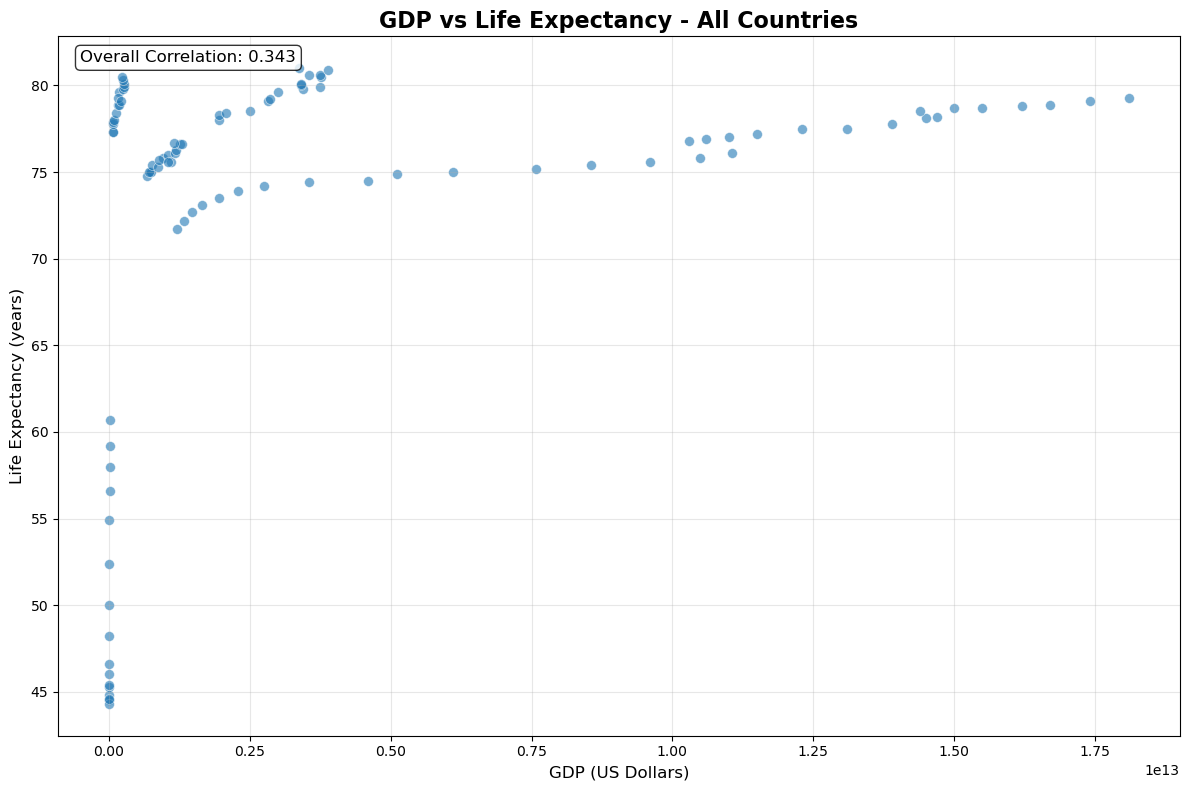


Interpretation of Overall Scatter Plot:
- Each point represents one country-year observation
- Pattern shows relationship between GDP (x-axis) and Life Expectancy (y-axis)
- Correlation value indicates strength of linear relationship
- Cloud shape shows variability in the relationship



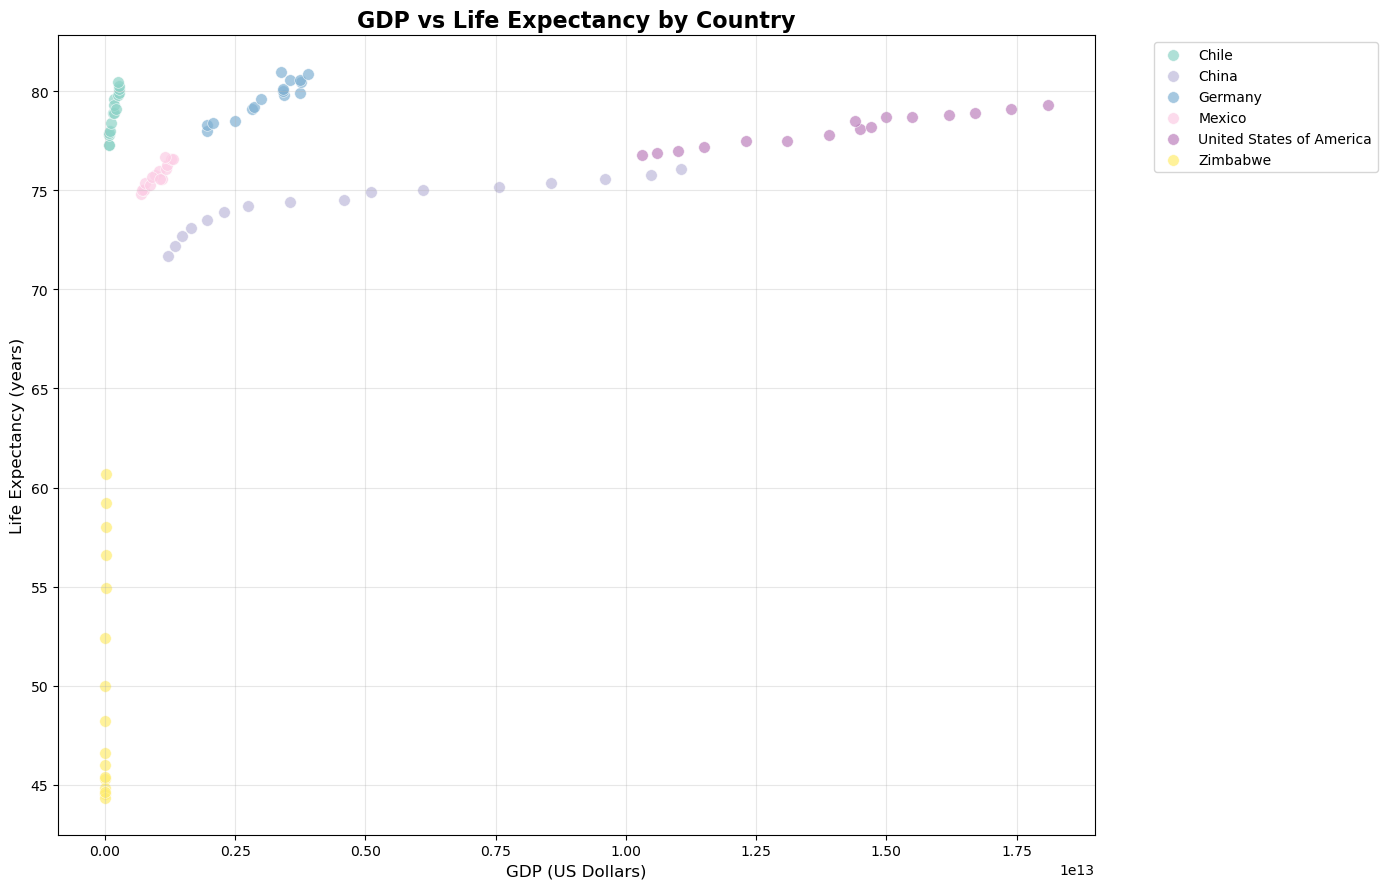


**Interpretation of Colored Scatter Plot**:
- Colors distinguish different countries
- Shows if countries cluster together or spread out
- Helps identify country-specific patterns
- Legend shows which color represents which country



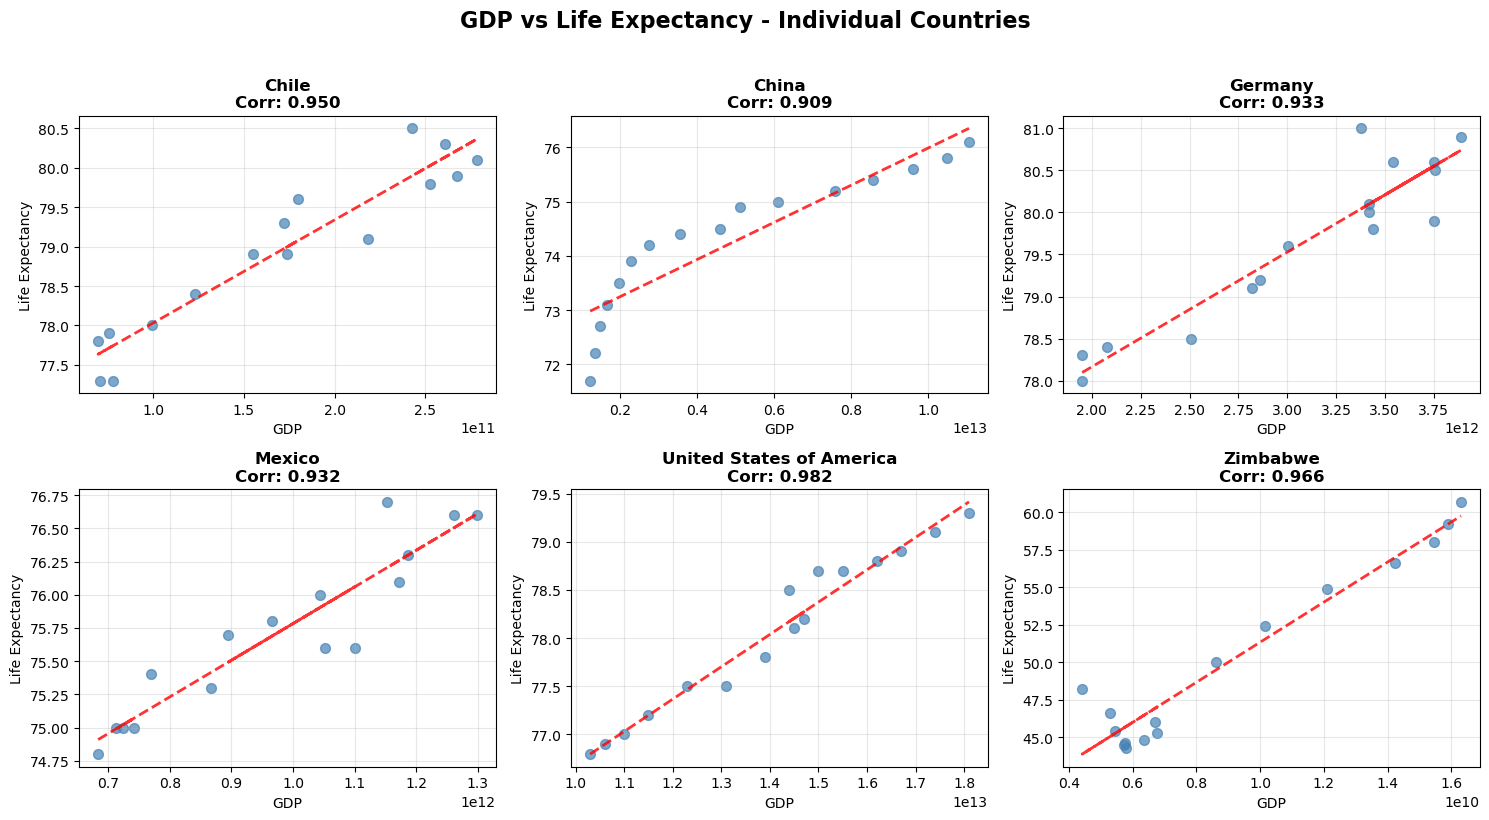


**Interpretation of Facet Grid**:
- Each subplot shows one country's data
- Red dashed line shows linear trend
- Correlation coefficient in title
- Allows country-by-country comparison
- Empty plots hidden for cleaner display



In [35]:
# Scatter Plot visualizations

# 1. Overall Scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['GDP'], df_clean['Life_expectancy'], 
            alpha=0.6, edgecolors='w', linewidth=0.5, s=50)

plt.title('GDP vs Life Expectancy - All Countries', fontsize=16, fontweight='bold')
plt.xlabel('GDP (US Dollars)', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add correlation text
plt.text(0.02, 0.98, f'Overall Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("""
Interpretation of Overall Scatter Plot:
- Each point represents one country-year observation
- Pattern shows relationship between GDP (x-axis) and Life Expectancy (y-axis)
- Correlation value indicates strength of linear relationship
- Cloud shape shows variability in the relationship
""")


plt.figure(figsize=(14, 9))

# Assign colors
countries = df_clean['Country'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(countries)))

for country, color in zip(countries, colors):
    country_data = df_clean[df_clean['Country'] == country]
    plt.scatter(country_data['GDP'], country_data['Life_expectancy'], 
                color=color, alpha=0.7, s=70, label=country, 
                edgecolors='w', linewidth=0.5)

plt.title('GDP vs Life Expectancy by Country', fontsize=16, fontweight='bold')
plt.xlabel('GDP (US Dollars)', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print("""
**Interpretation of Colored Scatter Plot**:
- Colors distinguish different countries
- Shows if countries cluster together or spread out
- Helps identify country-specific patterns
- Legend shows which color represents which country
""")


# 3. Facet grid - one plot per country
num_countries = len(countries)
rows = (num_countries + 2) // 3  # Calculate rows needed for 3 columns
fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
axes = axes.flatten()

for idx, country in enumerate(countries):
    if idx < len(axes):
        country_data = df_clean[df_clean['Country'] == country]
        
        # Plot scatter
        axes[idx].scatter(country_data['GDP'], country_data['Life_expectancy'], 
                         alpha=0.7, s=50, color='steelblue')
        
        # Add trend line (linear regression)
        if len(country_data) > 1:
            z = np.polyfit(country_data['GDP'], country_data['Life_expectancy'], 1)
            p = np.poly1d(z)
            axes[idx].plot(country_data['GDP'], p(country_data['GDP']), 
                          "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation for this country
        country_corr = country_data['GDP'].corr(country_data['Life_expectancy'])
        
        # Set title with correlation
        axes[idx].set_title(f'{country}\nCorr: {country_corr:.3f}', fontweight='bold')
        axes[idx].set_xlabel('GDP')
        axes[idx].set_ylabel('Life Expectancy')
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(countries), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('GDP vs Life Expectancy - Individual Countries', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
**Interpretation of Facet Grid**:
- Each subplot shows one country's data
- Red dashed line shows linear trend
- Correlation coefficient in title
- Allows country-by-country comparison
- Empty plots hidden for cleaner display
""")


"""
## Time Series Analysis
### Tracking Changes Over Time

**Time Series Plots**:
1. **GDP Over Time**: Economic growth trajectories
2. **Life Expectancy Over Time**: Health improvements
3. **Dual-Axis Plots**: Combined view for individual countries

**Growth Analysis**:
- Calculate percentage growth in GDP
- Calculate absolute growth in Life Expectancy
- Compare which countries improved most
- Identify development patterns


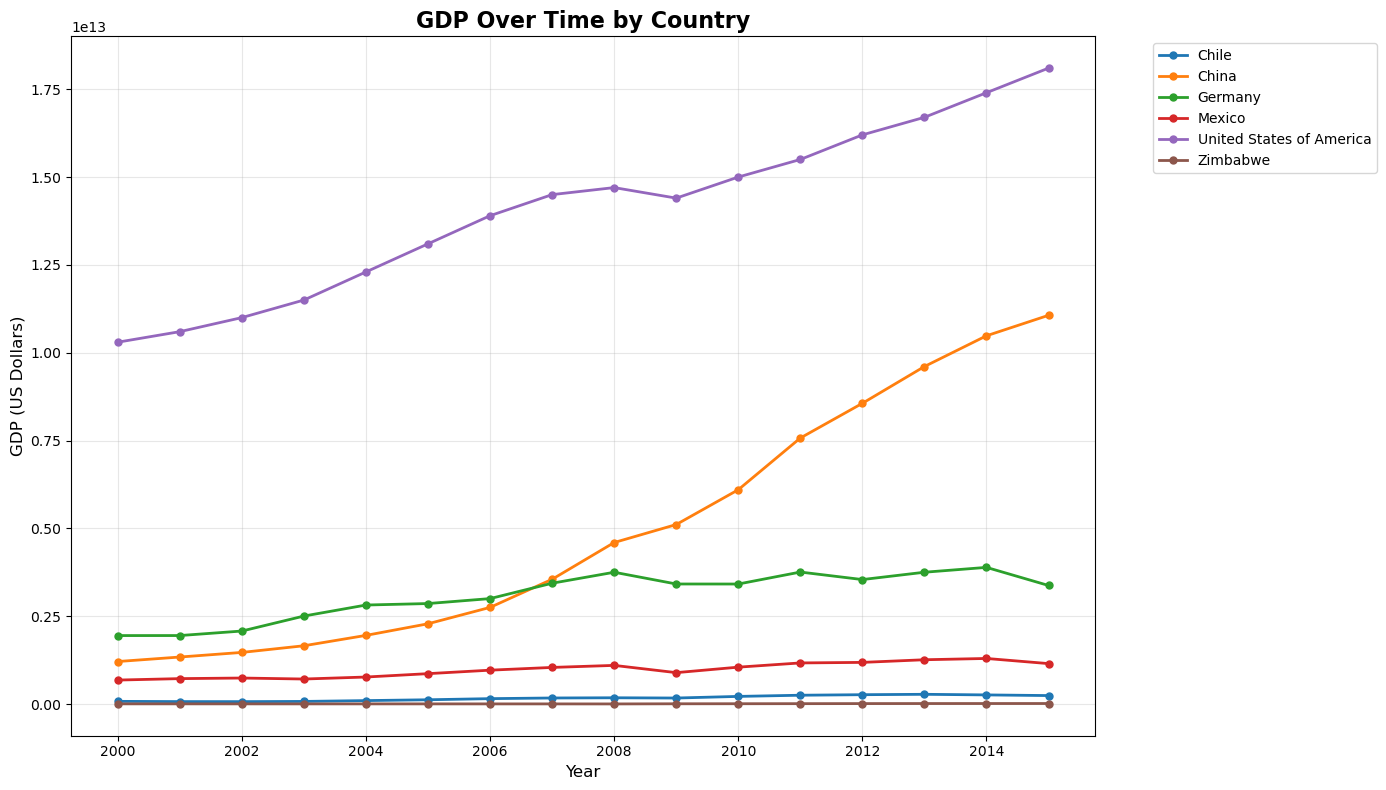


**GDP Over Time Interpretation**:
- Shows economic growth/decline for each country
- Steeper slopes indicate faster growth
- Comparing lines shows relative economic performance
- Marker points show actual data years



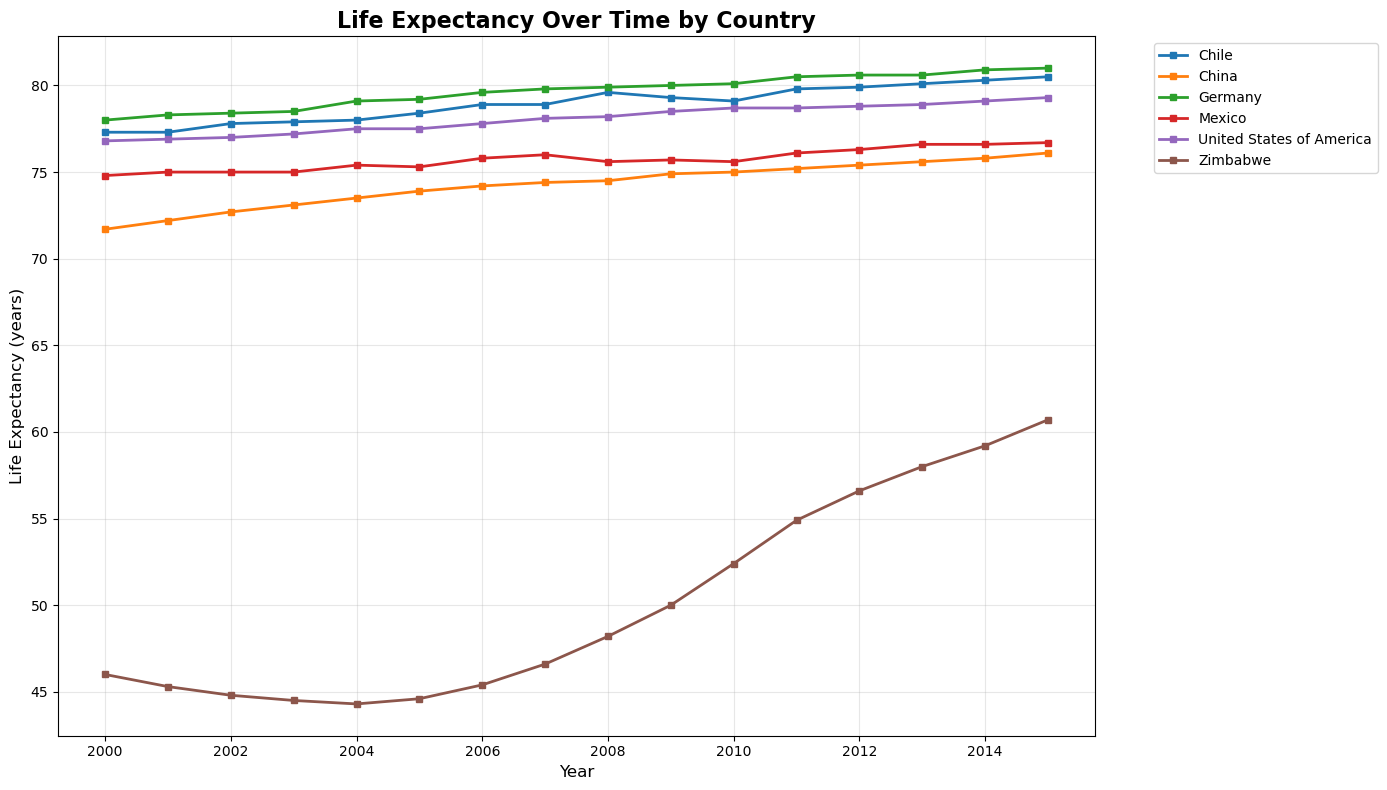


**Life Expectancy Over Time Interpretation**:
- Shows health improvements over time
- Most countries show upward trends (increasing life expectancy)
- Different markers (squares) distinguish from GDP plot
- Y-axis range shows typical life expectancy values


GROWTH ANALYSIS:


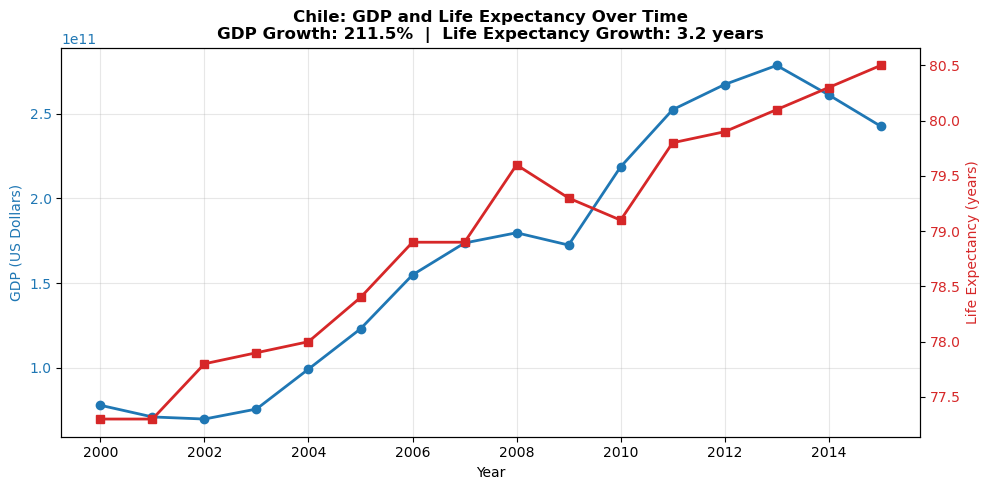

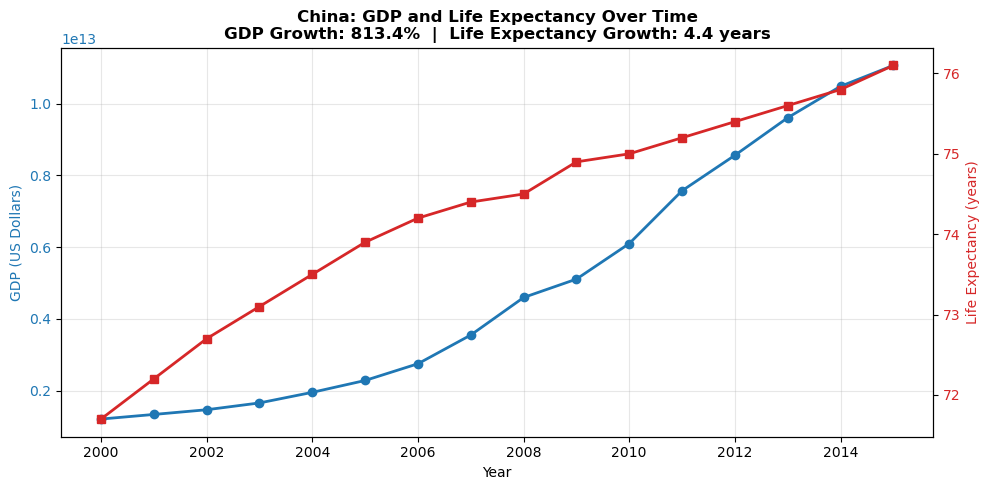

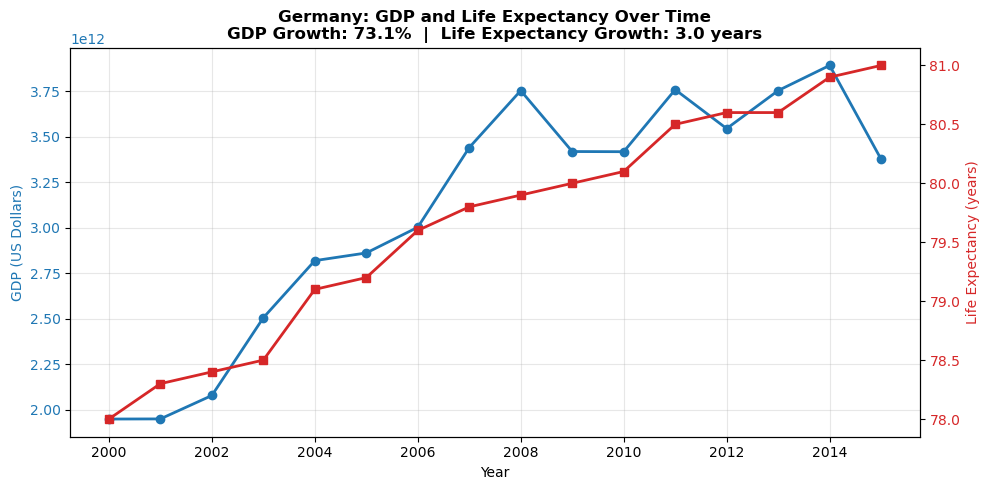

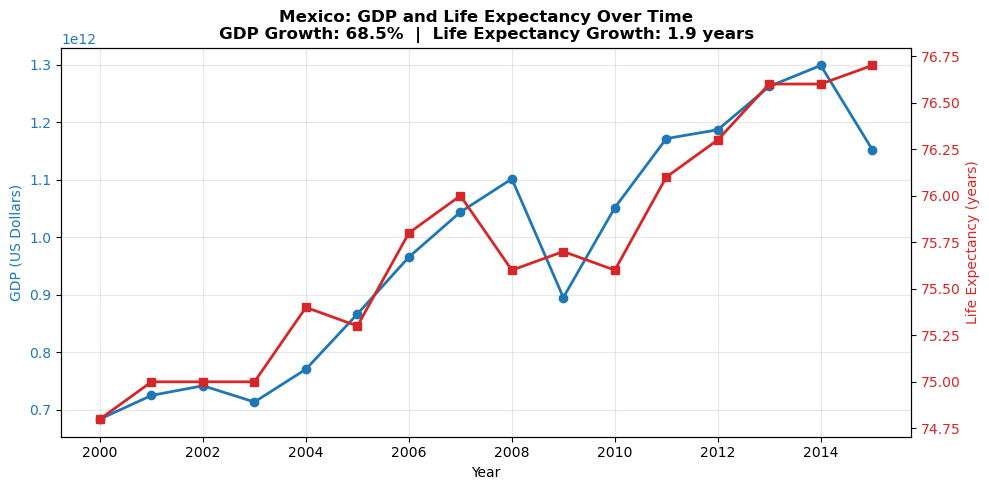

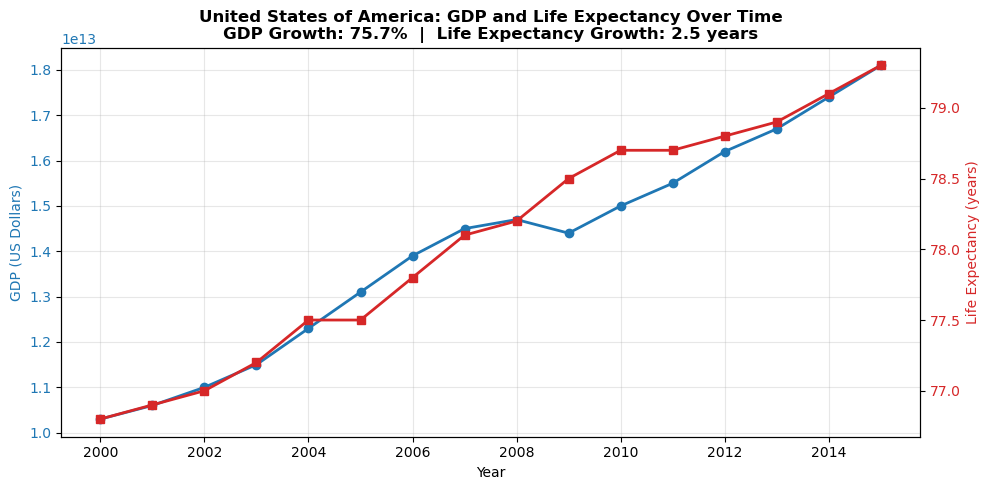

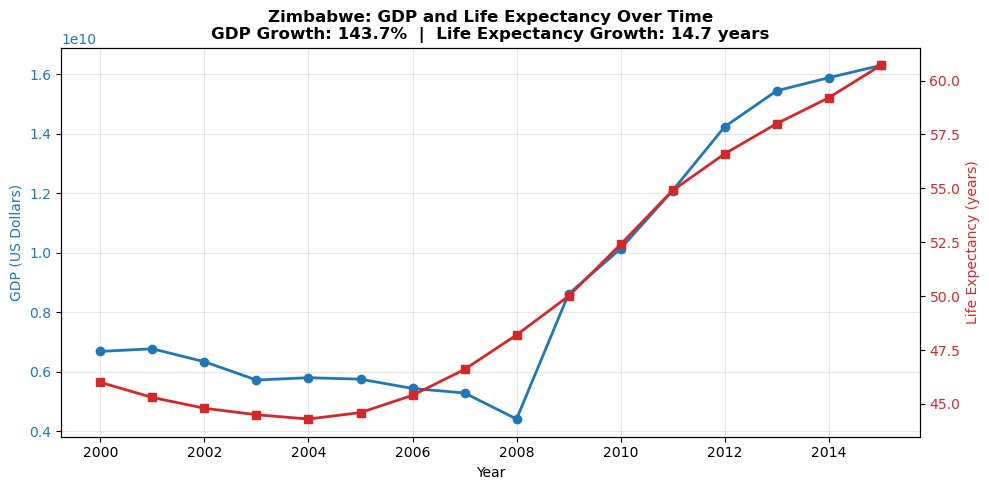


**Dual-Axis Plot Interpretation**:
- Blue line (left axis): GDP over time
- Red line (right axis): Life Expectancy over time
- Allows comparison of economic and health trends
- Shows if improvements happen simultaneously


Growth summary:


,Country,GDP_Growth_%,Life_Growth_Years,First_Year,Last_Year
1,China,813.418913,4.4,2000,2015
0,Chile,211.475850,3.2,2000,2015
5,Zimbabwe,143.718552,14.7,2000,2015
4,United States of America,75.728155,2.5,2000,2015
2,Germany,73.112644,3.0,2000,2015
3,Mexico,68.545801,1.9,2000,2015



    **Growth Summary Interpretation**:
    - GDP Growth (%): Percentage increase in GDP over the period
    - Life Growth (Years): Increase in life expectancy in years
    - Positive values indicate improvement
    - Negative values indicate decline
    


In [39]:
# 1. GDP Over Time by Country
plt.figure(figsize=(14, 8))

for country in countries:
    country_data = df_clean[df_clean['Country'] == country].sort_values('Year')
    plt.plot(country_data['Year'], country_data['GDP'], 
             marker='o', linewidth=2, markersize=5, label=country)

plt.title('GDP Over Time by Country', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP (US Dollars)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print("""
**GDP Over Time Interpretation**:
- Shows economic growth/decline for each country
- Steeper slopes indicate faster growth
- Comparing lines shows relative economic performance
- Marker points show actual data years
""")

# 2. Life Expectancy Over Time by Country
plt.figure(figsize=(14, 8))

for country in countries:
    country_data = df_clean[df_clean['Country'] == country].sort_values('Year')
    plt.plot(country_data['Year'], country_data['Life_expectancy'], 
             marker='s', linewidth=2, markersize=5, label=country)

plt.title('Life Expectancy Over Time by Country', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print("""
**Life Expectancy Over Time Interpretation**:
- Shows health improvements over time
- Most countries show upward trends (increasing life expectancy)
- Different markers (squares) distinguish from GDP plot
- Y-axis range shows typical life expectancy values
""")


# 3. Combined Plot for each country
print("\nGROWTH ANALYSIS:")
growth_data = []

for country in countries:
    country_data = df_clean[df_clean['Country'] == country].sort_values('Year')
    
    if len(country_data) > 1:
        # Calculate growth
        first_year = country_data.iloc[0]
        last_year = country_data.iloc[-1]
        
        gdp_growth_pct = ((last_year['GDP'] - first_year['GDP']) / first_year['GDP']) * 100
        life_growth = last_year['Life_expectancy'] - first_year['Life_expectancy']
        
        growth_data.append({
            'Country': country,
            'GDP_Growth_%': gdp_growth_pct,
            'Life_Growth_Years': life_growth,
            'First_Year': first_year['Year'],
            'Last_Year': last_year['Year']
        })
        
        # Create individual dual-axis plot for each country
        fig, ax1 = plt.subplots(figsize=(10, 5))
        
        color = 'tab:blue'
        ax1.set_xlabel('Year')
        ax1.set_ylabel('GDP (US Dollars)', color=color)
        ax1.plot(country_data['Year'], country_data['GDP'], 
                color=color, marker='o', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, alpha=0.3)
        
        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('Life Expectancy (years)', color=color)
        ax2.plot(country_data['Year'], country_data['Life_expectancy'], 
                color=color, marker='s', linewidth=2)
        ax2.tick_params(axis='y', labelcolor=color)
        
        plt.title(f'{country}: GDP and Life Expectancy Over Time\n'
                 f'GDP Growth: {gdp_growth_pct:.1f}%  |  '
                 f'Life Expectancy Growth: {life_growth:.1f} years', 
                 fontsize=12, fontweight='bold')
        fig.tight_layout()
        plt.show()

print("""
**Dual-Axis Plot Interpretation**:
- Blue line (left axis): GDP over time
- Red line (right axis): Life Expectancy over time
- Allows comparison of economic and health trends
- Shows if improvements happen simultaneously
""")

# Display growth summary
if growth_data:
    growth_df = pd.DataFrame(growth_data)
    print("\nGrowth summary:")
    display(growth_df.sort_values('GDP_Growth_%', ascending=False))
    
    print("""
    **Growth Summary Interpretation**:
    - GDP Growth (%): Percentage increase in GDP over the period
    - Life Growth (Years): Increase in life expectancy in years
    - Positive values indicate improvement
    - Negative values indicate decline
    """)


## Statistical Summary
### Quantitative Analysis and Rankings

What We Calculate:
1. Average Values: Mean GDP and Life Expectancy per country
2. Country Rankings: Who performs best/worst?
3. Extreme Values: Identifying outliers and exceptional cases
4. Efficiency Ratio: GDP per year of life expectancy

Why These Metrics Matter:
- Helps compare country performance
- Identifies development patterns
- Shows economic efficiency for health outcomes
- Provides benchmarks for policy targets

In [42]:
#Statistical summary
print("STATISTICAL SUMMARY AND INSIGHTS")

# 1. Calculate averages
averages = df_clean.groupby('Country').agg({
    'GDP': ['mean', 'median', 'min', 'max'],
    'Life_expectancy': ['mean', 'median', 'min', 'max']
}).round(2)

print("\nAverage values by country :")
display(averages)

# 2. Rankings
print("\nCountry rankings:")

# GDP Ranking
gdp_ranking = averages[('GDP', 'mean')].sort_values(ascending=False)
print("GDP Ranking (Highest to Lowest):")
for i, (country, gdp) in enumerate(gdp_ranking.items(), 1):
    print(f"  {i}. {country}: ${gdp:,.0f}")

print("\nLife Expectancy Ranking (Highest to Lowest):")
life_ranking = averages[('Life_expectancy', 'mean')].sort_values(ascending=False)
for i, (country, life) in enumerate(life_ranking.items(), 1):
    print(f"  {i}. {country}: {life:.1f} years")

# 3. Find extremes
highest_gdp = gdp_ranking.index[0]
lowest_gdp = gdp_ranking.index[-1]
highest_life = life_ranking.index[0]
lowest_life = life_ranking.index[-1]

print(f"\nExtreme Values:")
print(f"* Highest average GDP: {highest_gdp} (${gdp_ranking[0]:,.0f})")
print(f"* Lowest average GDP: {lowest_gdp} (${gdp_ranking[-1]:,.0f})")
print(f"* Highest average Life Expectancy: {highest_life} ({life_ranking[0]:.1f} years)")
print(f"* Lowest average Life Expectancy: {lowest_life} ({life_ranking[-1]:.1f} years)")

# 4. Calculate GDP to Life Expectancy ratio
print(f"\nEfficiency ratio (GDP per Year of Life Expectancy):")
efficiency_data = []
for country in countries:
    country_data = df_clean[df_clean['Country'] == country]
    avg_gdp = country_data['GDP'].mean()
    avg_life = country_data['Life_expectancy'].mean()
    ratio = avg_gdp / avg_life if avg_life > 0 else 0
    efficiency_data.append({'Country': country, 'GDP_per_Life_Year': ratio})
    print(f"  {country}: ${ratio:,.0f} GDP per year of life expectancy")

# Sort by efficiency
efficiency_df = pd.DataFrame(efficiency_data).sort_values('GDP_per_Life_Year')
print(f"\nMost Efficient Countries (Lowest GDP per Life Year):")
for i, row in efficiency_df.head().iterrows():
    print(f"  {i+1}. {row['Country']}: ${row['GDP_per_Life_Year']:,.0f}")

STATISTICAL SUMMARY AND INSIGHTS

Average values by country :


GDP                              \
                                  mean        median           min   
Country                                                              
Chile                     1.697888e+11  1.729975e+11  6.973681e+10   
China                     4.957714e+12  4.075195e+12  1.211350e+12   
Germany                   3.094776e+12  3.396350e+12  1.949950e+12   
Mexico                    9.766506e+11  1.004376e+12  6.836480e+11   
United States of America  1.407500e+13  1.445000e+13  1.030000e+13   
Zimbabwe                  9.062580e+09  6.733671e+09  4.415703e+09   

                                       Life_expectancy                     
                                   max            mean median   min   max  
Country                                                                    
Chile                     2.783840e+11           78.94  79.00  77.3  80.5  
China                     1.106470e+13           74.26  74.45  71.7  76.1  
Germany                   3.890610e+12           79.66  79.85  78.0  81.0  
Mexico                    1.298460e+12           75.72  75.65  74.8  76.7  
United States of America  1.810000e+13           78.06  78.15  76.8  79.3  
Zimbabwe                  1.630467e+10           50.09  47.40  44.3  60.7


Country rankings:
GDP Ranking (Highest to Lowest):
  1. United States of America: $14,075,000,000,000
  2. China: $4,957,713,750,000
  3. Germany: $3,094,775,625,000
  4. Mexico: $976,650,625,000
  5. Chile: $169,788,845,015
  6. Zimbabwe: $9,062,579,595

Life Expectancy Ranking (Highest to Lowest):
  1. Germany: 79.7 years
  2. Chile: 78.9 years
  3. United States of America: 78.1 years
  4. Mexico: 75.7 years
  5. China: 74.3 years
  6. Zimbabwe: 50.1 years

Extreme Values:
* Highest average GDP: United States of America ($14,075,000,000,000)
* Lowest average GDP: Zimbabwe ($9,062,579,595)
* Highest average Life Expectancy: Germany (79.7 years)
* Lowest average Life Expectancy: Zimbabwe (50.1 years)

Efficiency ratio (GDP per Year of Life Expectancy):
  Chile: $2,150,757,280 GDP per year of life expectancy
  China: $66,759,316,613 GDP per year of life expectancy
  Germany: $38,851,635,936 GDP per year of life expectancy
  Mexico: $12,898,398,679 GDP per year of life expectancy
  Uni

## Final Conclusions and Insights
### Summary of Findings and Implications

Key Questions Answered:
1. Is there a relationship between GDP and Life Expectancy?
2. How strong is this relationship?
3. Do all countries follow the same pattern?
4. What are the policy implications?

Limitations to Consider:
- Correlation does not equal Causation
- Other factors influence health outcomes
- Data quality and completeness
- Time period limitations

In [44]:
print(f"\nDataset summary:")
print(f"* Total countries analyzed: {len(countries)}")
print(f"* Time period: {df_clean['Year'].min()} to {df_clean['Year'].max()}")
print(f"* Total data points: {len(df_clean)}")
print(f"* Clean data points: {len(df_clean)}")

print(f"\nKey findings:")

# Correlation findings
if 'corr_df' in locals() and not corr_df.empty:
    print(f"1. Overall correlation: {correlation:.3f}")
    
    if correlation > 0.5:
        print("   -> Strong positive relationship: Higher GDP strongly associates with longer life")
        print("   Implication: Economic development is closely linked to health outcomes")
    elif correlation > 0.3:
        print("   -> Moderate positive relationship: Economic growth tends to improve life expectancy")
        print("   Implication: Wealth creation supports better healthcare and living conditions")
    elif correlation > 0.1:
        print("   -> Weak positive relationship: Slight tendency for wealthier countries to have longer lives")
        print("   Implication: GDP alone is not enough - other factors matter significantly")
    else:
        print("   -> Little to no relationship: GDP alone doesn't strongly predict life expectancy")
        print("   Implication: Health outcomes depend more on healthcare systems than economic output")
    
    print(f"\n2. Country-specific correlations range from {corr_df['Correlation'].min():.3f} to {corr_df['Correlation'].max():.3f}")
    print(f"   Average country correlation: {corr_df['Correlation'].mean():.3f}")
    print("   Implication: The relationship varies significantly between countries")

# Growth findings
if 'growth_df' in locals() and not growth_df.empty:
    print(f"\n3. Growth Patterns:")
    
    max_gdp_growth = growth_df.loc[growth_df['GDP_Growth_%'].idxmax()]
    max_life_growth = growth_df.loc[growth_df['Life_Growth_Years'].idxmax()]
    
    print(f"   * Fastest GDP growth: {max_gdp_growth['Country']} ({max_gdp_growth['GDP_Growth_%']:.1f}%)")
    print(f"   * Fastest Life Expectancy growth: {max_life_growth['Country']} (+{max_life_growth['Life_Growth_Years']:.1f} years)")
    
    # Check if same country has both high GDP and life growth
    combined_growth = growth_df.copy()
    combined_growth['Combined_Score'] = combined_growth['GDP_Growth_%'] + combined_growth['Life_Growth_Years'] * 10
    best_overall = combined_growth.loc[combined_growth['Combined_Score'].idxmax()]
    
    print(f"   * Best overall development: {best_overall['Country']}")
    print(f"     (High GDP growth + Life Expectancy improvement)")

# Efficiency findings
if 'efficiency_df' in locals():
    print(f"\n4. Economic Efficiency for Health:")
    most_efficient = efficiency_df.iloc[0]
    least_efficient = efficiency_df.iloc[-1]
    
    print(f"   * Most efficient: {most_efficient['Country']} (${most_efficient['GDP_per_Life_Year']:,.0f} per life year)")
    print(f"   * Least efficient: {least_efficient['Country']} (${least_efficient['GDP_per_Life_Year']:,.0f} per life year)")
    print("   Implication: Some countries achieve good health outcomes with less economic resources")

print(f"\nPRACTICAL IMPLICATIONS FOR POLICYMAKERS:")
print("1. Economic Growth: Generally supports better health, but isn't sufficient alone")
print("2. Healthcare Investment: Direct healthcare spending often more effective than GDP growth")
print("3. Education & Prevention: Public health initiatives can improve outcomes independently of GDP")
print("4. Equity Matters: How wealth is distributed affects health more than total wealth")
print("5. Country Context: Strategies should be tailored to each country's specific situation")

print(f"\nLIMITATIONS OF THIS ANALYSIS:")
print("* Correlation does not equal Causation: We can't prove GDP causes longer life")
print("* Omitted Variables: Education, healthcare access, lifestyle factors not included")
print("* Data Quality: Depends on accuracy of WHO and World Bank reporting")
print("* Time Lag: Health outcomes may reflect past, not current, economic conditions")



Dataset summary:
* Total countries analyzed: 6
* Time period: 2000 to 2015
* Total data points: 96
* Clean data points: 96

Key findings:
1. Overall correlation: 0.343
   -> Moderate positive relationship: Economic growth tends to improve life expectancy
   Implication: Wealth creation supports better healthcare and living conditions

2. Country-specific correlations range from 0.909 to 0.982
   Average country correlation: 0.945
   Implication: The relationship varies significantly between countries

3. Growth Patterns:
   * Fastest GDP growth: China (813.4%)
   * Fastest Life Expectancy growth: Zimbabwe (+14.7 years)
   * Best overall development: China
     (High GDP growth + Life Expectancy improvement)

4. Economic Efficiency for Health:
   * Most efficient: Zimbabwe ($180,912,381 per life year)
   * Least efficient: United States of America ($180,304,243,395 per life year)
   Implication: Some countries achieve good health outcomes with less economic resources

PRACTICAL IMPLICA

RECOMMENDATIONS FOR FURTHER RESEARCH:
1. Add more countries for broader comparison
2. Include additional variables (healthcare spending, education levels)
3. Use more advanced statistical models (multiple regression)
4. Analyze specific time periods (pre/post major policy changes)
5. Study mechanisms: How exactly does GDP affect health outcomes?